In [1]:
from lib.drivers import *
#from lib.interface import *
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
%matplotlib widget
plt.close('all')

In [3]:

class BaseInterface:
    """Classe base per interfacce strumentali con widget e grafici live."""

    def __init__(self, log_max_lines=10):
        """Inizializza stato condiviso, widget di base e area output."""
        self.fig = None
        self.axes = None
        self.update_timer = None
        self.widgets = {}
        self.artists = None
        
        
        self.save_data_bool = False
        self.log_max_lines = int(log_max_lines)
        self._log_lines = deque(maxlen=self.log_max_lines)
        
        self.widgets["save_data"] = widgets.Checkbox(value=False, description='Salva dati su file', disabled=False, indent=False)
        self.widgets["save_data"].observe(lambda change: setattr(self, "save_data_bool", change['new']), names='value')

        self.output = widgets.Output()
    
    def _log(self, message):
        """Scrive un messaggio in output mantenendo solo le ultime N righe."""
        if message is None:
            return
        
        text = str(message)
        lines = text.splitlines() if text else [""]
        for line in lines:
            self._log_lines.append(line)
        
        with self.output:
            self.output.clear_output(wait=True)
            #print("\n".join(self._log_lines))
            self.output.append_stdout("\n".join(self._log_lines) + "\n")
    
    def _init_plot(self, suptitle, ncols, nrows, plot_types, plot_titles=None, xlabels=None, ylabels=None):
        """Inizializza figura, assi e artist in base alla configurazione.

        Args:
            suptitle (str): Titolo globale della figura.
            ncols (int): Numero di colonne della griglia subplot.
            nrows (int): Numero di righe della griglia subplot.
            plot_types (list[list[str | None]]): Tipo grafico per ogni asse
                (``image``, ``line``, ``scatter`` o ``None``).
            plot_titles (list[list[str]] | None): Titoli per ogni subplot.
            xlabels (list[list[str]] | None): Etichette asse x.
            ylabels (list[list[str]] | None): Etichette asse y.
        """
        with plt.ioff():

            self.fig, self.axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(8*ncols, 6*nrows))
            
            self.fig.suptitle(suptitle)
            
            if ncols == 1 and nrows == 1:
                self.axes = np.array([[self.axes]])
            elif ncols == 1:
                self.axes = self.axes[:, np.newaxis]
            elif nrows == 1:
                self.axes = self.axes[np.newaxis, :]
            
            self.artists = np.empty((nrows, ncols), dtype=object) 
            for i in range(nrows):
                for j in range(ncols):
                    plot_type = plot_types[i][j]
                    if plot_type == 'image':
                        self.artists[i, j] = self.axes[i, j].imshow(np.zeros((10, 10)), cmap='gray')
                        self.axes[i, j].set_aspect('equal')
                    elif plot_type == 'line':
                        self.artists[i, j], = self.axes[i, j].plot([], [])
                    elif plot_type == 'scatter':
                        self.artists[i, j] = self.axes[i, j].scatter([], [])
                    
                    if plot_titles is not None:
                        self.axes[i, j].set_title(plot_titles[i][j])
                    if xlabels is not None and ylabels is not None:
                        self.axes[i, j].set_xlabel(xlabels[i][j])
                        self.axes[i, j].set_ylabel(ylabels[i][j])

    def _start_update_plot(self, interval=100):
        """Avvia timer di aggiornamento periodico del grafico.

        Args:
            interval (int): Intervallo timer in millisecondi.
        """
        self.update_timer = self.fig.canvas.new_timer(interval=interval)
        self.update_timer.add_callback(self._update_plot)
        self.update_timer.start()
    
    def _stop_update_plot(self):
        """Ferma il timer di aggiornamento grafico se attivo."""
        if self.update_timer is not None:
            self.update_timer.stop()
            self.update_timer = None
        
    def _set_lims(self, lims, plot_types):
        """Imposta i limiti di tutti gli assi in base al tipo di grafico.

        Args:
            lims (list[list[tuple]]): Limiti target per ogni asse.
            plot_types (list[list[str | None]]): Tipo grafico per ogni asse.
        """
        for i in range(len(self.axes)):
            for j in range(len(self.axes[i])):

                if plot_types[i][j] is None:
                    continue
                
                if plot_types[i][j] == 'image':
                    self.axes[i, j].set_clim(*lims[i][j])

                if plot_types[i][j] in ['line', 'scatter']:
                    self.axes[i, j].set_xlim(lims[i][j][0])
                    self.axes[i, j].set_ylim(lims[i][j][1])
    
    def _set_lim(self, lim, plot_type, i, j):
        """Imposta i limiti di un singolo asse.

        Args:
            lim (tuple): Limiti da applicare (clim o coppia x/y).
            plot_type (str | None): Tipo grafico dell'asse.
            i (int): Indice riga asse.
            j (int): Indice colonna asse.
        """
        if plot_type is None:
            return
        
        if plot_type == 'image':
            self.axes[i, j].set_clim(*lim)

        if plot_type in ['line', 'scatter']:
            self.axes[i, j].set_xlim(lim[0])
            self.axes[i, j].set_ylim(lim[1])
    
    def _update_plot(self):
        """Hook di aggiornamento grafico da implementare nelle sottoclassi."""
        pass
            
class BilanciaInterface(BaseInterface):
    """Interfaccia widget per acquisizione live da microbilancia."""

    def __init__(self, port=None, use_dummy=False, log_max_lines=10):
        """Costruisce UI, grafici e callback per la microbilancia.

        Args:
            port (str | None): Porta seriale preselezionata.
        """
        super().__init__(log_max_lines=log_max_lines)

        self.bilancia = None
        self.ports = list_ports.comports()
        self.selected_port = port
        self.use_dummy = use_dummy
        self.t0 = None

        self.thickness_data = []
        self.rate_data = []
        self.timestamps = []

        self.widgets["connect_btn"] = widgets.Button(description="Connect Bilancia")
        self.widgets["disconnect_btn"] = widgets.Button(description="Disconnect Bilancia")

        self._init_plot(
            suptitle="Bilancia Interface",
            ncols=2,
            nrows=1,
            plot_types=[['line', 'line']],
            plot_titles=[['Thickness', 'Rate']],
            xlabels=[['Tempo (s)', 'Tempo (s)']],
            ylabels=[['','']]
        )

        self.widgets["connect_btn"].on_click(lambda _: self.on_connect_btn())
        self.widgets["disconnect_btn"].on_click(lambda _: self.on_disconnect_btn())
        self.widgets["port_select"] = widgets.Dropdown(options=[(port.device, port.device) for port in self.ports], description="Port:")
        self.widgets["port_select"].observe(lambda change: setattr(self, "selected_port", change['new']), names='value')

        self.show()
    
    def show(self):
        """Visualizza widget principali e canvas della figura."""
        display(self.output)
        display(widgets.HBox([self.widgets["connect_btn"], self.widgets["disconnect_btn"], self.widgets["port_select"], self.widgets["save_data"]]))
        display(self.fig.canvas)
    
    def on_connect_btn(self):
        """Gestisce il click di connessione e avvia lettura continua."""
        if not self.use_dummy and self.selected_port is None:
            self._log("Porta non selezionata")
            return
        
        try:
            if self.use_dummy:
                self.bilancia = DummyBilancia()
            else:
                self.bilancia = Bilancia(self.selected_port)
            if self.use_dummy:
                self._log("Connected to dummy bilancia")
            else:
                self._log(f"Connected to bilancia on port {self.selected_port}")
        except Exception as e:
            self._log(f"Failed to connect to bilancia: {e}")
            self.bilancia = None
            return
        
        self.bilancia.start_continuous_read(data=["Sensor 1 rate", "Sensor 1 thickness"])
        self._start_update_plot(interval=100)
        
    def on_disconnect_btn(self):
        """Gestisce il click di disconnessione e arresta la lettura."""
        if self.bilancia is not None:
            self.bilancia.stop_continuous_read()
            self.bilancia.close()
            self.bilancia = None
            self._log("Bilancia disconnected.")
        else:
            self._log("No bilancia to disconnect.")

        self._stop_update_plot()
        self.t0 = None
    
    def _update_plot(self):
        """Aggiorna serie spessore/rate leggendo l'ultimo campione disponibile."""
        global save_dir_name
        
        if self.bilancia is None:
            self._log("No bilancia connected.")
            self._stop_update_plot()
            return
        
        data = self.bilancia.get_latest_data()

        if data is None:
            return
        
        try:
            (r, spessore), timestamp = data
            spessore = float(spessore)
            r = float(r)
            timestamp = float(timestamp)
            
            if self.save_data_bool:
                data_filename = f"{save_dir_name}/data/points.txt"
                with open(data_filename, "a") as f:
                    f.write(f"{timestamp}\t{spessore}\t{r}\n")
            
            if self.t0 is None:
                self.t0 = timestamp
            
            t_rel = timestamp - self.t0
            self._log(t_rel)

            self.thickness_data.append(spessore)
            self.rate_data.append(r)
            self.timestamps.append(t_rel)

            self.artists[0, 0].set_data(self.timestamps, self.thickness_data)
            self.artists[0, 1].set_data(self.timestamps, self.rate_data)

            self.axes[0, 0].relim()
            self.axes[0, 0].autoscale_view()

            self.axes[0, 1].relim()
            self.axes[0, 1].autoscale_view()
            
            if len(self.timestamps) > 100000:
                self.timestamps.pop(0)
                self.thickness_data.pop(0)
                self.rate_data.pop(0)

            self.fig.canvas.draw_idle()
        
        except Exception as e:
            # Scarta campione corrotto, non uccidere l'update loop
            self._log("Dati corrotti ricevuti, scartando campione")
            self._log(e)
            return

class ElectrometerInterface(BaseInterface):
    
    def __init__(self, port=None, use_dummy=False, expected_current_order=-9, log_max_lines=10):
        super().__init__(log_max_lines=log_max_lines)

        self.keithley = None
        self.ports = list_ports.comports()
        self.selected_port = port
        self.use_dummy = use_dummy
        self.expected_current_order = int(expected_current_order)
        self.t0 = None

        self.resistance_data = []
        self.current_data = []
        self.time_data = []
        self.range_data = []

        self.widgets["connect_btn"] = widgets.Button(description="Connect Keithley")
        self.widgets["disconnect_btn"] = widgets.Button(description="Disconnect Keithley")

        self.widgets["enable_output"] = widgets.Checkbox(value=False, description='Activate voltage source', disabled=False, indent=False)
        self.widgets["enable_output"].observe(lambda change: self.on_enable_output_change(change['new']), names='value')

        self.widgets["set_source:voltage"] = widgets.FloatSlider(value=0.1, min=0, max=10, step=0.1, description='Source Voltage (V):')
        self.widgets["set_source:voltage"].observe(lambda change: self.on_set_source_voltage_change(change['new']), names='value')
        
        self.widgets["empty_data_plot"] = widgets.Button(description="Empty data plot")

        self._init_plot(
            suptitle="Keithley Interface",
            ncols=2,
            nrows=1,
            plot_types=[['line', 'line']],
            plot_titles=[['Current vs Time', 'Resistance vs Time']],
            ylabels=[['Current (A)', 'Resistance']],
            xlabels=[['Time', 'Time']]
        )

        self.widgets["connect_btn"].on_click(lambda _: self.on_connect_btn())
        self.widgets["disconnect_btn"].on_click(lambda _: self.on_disconnect_btn())
        self.widgets["port_select"] = widgets.Dropdown(options=[(port.device, port.device) for port in self.ports], description="Port:")
        self.widgets["port_select"].observe(lambda change: setattr(self, "selected_port", change['new']), names='value')
        self.widgets["empty_data_plot"].on_click(lambda _: self.clear_figure())
        
        self.widgets["output"] = widgets.Output()
        self.output = self.widgets["output"]
        
        self.counter = 0

        self.show()
    
    def on_set_source_voltage_change(self, new_value):
        if self.keithley is not None:
            try:
                self.keithley.set_source_voltage(new_value)
                self._log(f"Source voltage set to {new_value} V.")
            except Exception as e:
                self._log(f"Failed to set source voltage: {e}")
        else:
            self._log("No Keithley connected. Cannot set source voltage.")

    def on_enable_output_change(self, new_value):
        if self.keithley is not None:
            try:
                if new_value:
                    self.keithley.set_output(True)
                    self._log("Voltage source activated.")
                else:
                    self.keithley.set_output(False)
                    self._log("Voltage source deactivated.")
            except Exception as e:
                self._log(f"Failed to change output state: {e}")
        else:
            self._log("No Keithley connected. Cannot change output state.")
        
    def show(self):
        display(self.output)
        display(widgets.HBox([self.widgets["connect_btn"], self.widgets["disconnect_btn"], self.widgets["port_select"], self.widgets["save_data"],  self.widgets["empty_data_plot"]]))
        display(self.fig.canvas)
        # another hbox below the fig for instrument settings (e.g. voltage source on/off)
        display(widgets.HBox([self.widgets["set_source:voltage"], self.widgets["enable_output"]]))
        
    def on_connect_btn(self):
        if not self.use_dummy and self.selected_port is None:
            self._log("Porta non selezionata")
            return
        
        try:
            if self.use_dummy:
                self.keithley = DummyElettrometroKeithley()
            else:
                self.keithley = ElettrometroKeithley(self.selected_port)
            if self.use_dummy:
                self._log("Connected to dummy Keithley")
            else:
                self._log(f"Connected to Keithley on port {self.selected_port}")
        except Exception as e:
            self._log(f"Failed to connect to Keithley: {e}")
            self.keithley = None
            return
        
        self.keithley.identify()
        #self.keithley.set_source_voltage(1)
        self.keithley.init_current_reading()
        self.counter = 0
        self._start_update_plot(interval=50)
        
    def on_disconnect_btn(self):
            if self.keithley is not None:
                self.keithley.close()
                self.keithley = None
                self.resistance_data.clear()
                self.time_data.clear()
                self._log("Keithley disconnected.")
            else:
                self._log("No Keithley to disconnect.")

            self._stop_update_plot()
            self.t0 = None
            
    def clear_figure(self):
        self.resistance_data = []
        self.current_data = []
        self.time_data = []
        self.range_data = []

    def _read_current_sample(self, range_order=None, autorange=False):
        if self.keithley is None:
            return None
        
        if autorange:
            self.keithley.set_autorange(func="CURR:DC", state=True)
            range_label = "Auto"
        else:
            if range_order is None:
                return None
            range_value = 10 ** range_order
            self.keithley.set_autorange(func="CURR:DC", state=False)
            self.keithley.set_manual_range("CURR:DC", range_value)
            range_label = range_value
        
        raw = self.keithley.read()
        parsed = self.keithley.parse_reading(raw, types=(float, float), units=False)
        if parsed is None:
            return None
        
        current, timestamp = parsed
        return current, timestamp, range_label

    def _update_current_order(self, readings):
        if not readings:
            return
        
        currents, _, ranges = zip(*readings)
        
        mean_current = np.mean(currents)

        order_of_magnitude = int(np.floor(np.log10(abs(mean_current)))) if mean_current != 0 else 0
        self.expected_current_order = order_of_magnitude

    def _update_plot(self):
        global save_dir_name
        
        if self.keithley is None:
            self._log("No Keithley connected.")
            self._stop_update_plot()
            return
        
        voltage = self.widgets["set_source:voltage"].value

        try:

            base_order = self.expected_current_order + 1  # lo strumento vuole il massimo valore atteso, quindi partiamo da un ordine di grandezza sopra quello medio delle misure
            readings = [
                self._read_current_sample(range_order=base_order, autorange=False),
                self._read_current_sample(range_order=base_order + 1, autorange=False),
                self._read_current_sample(autorange=True),
            ]
            readings = [reading for reading in readings if reading is not None]

            
            if not readings:
                self._log("No valid readings obtained from Keithley.")
                return
            
            if self.counter % 5 == 0:
                self._update_current_order(readings)
            
            
            self.counter += 1
            
            currents, times, ranges = zip(*readings)
            self.current_data.extend(currents)
            self.resistance_data.extend(voltage / np.array(currents))  # converte corrente in resistenza
            self.time_data.extend(times)
            self.range_data.extend(ranges)
            
            if self.save_data_bool:

                if not self.use_dummy:
                    data_filename = f"{save_dir_name}/data/points_keithley.txt"
                    with open(data_filename, "a") as f:
                        for curr, t, r in zip(currents, times, ranges):
                            f.write(f"{curr}\t{t}\t{r}\n")
                else:
                    for curr, t, r in zip(currents, times, ranges):
                        self._log(f"{curr}\t{t}\t{r}")

            # Gestione del tempo relativo (t0)
            if self.t0 is None:
                self.t0 = self.time_data[0]
                
            # Creiamo una lista temporanea con il tempo sottratto al t0 per far partire il grafico da zero
            rel_time = [t - self.t0 for t in self.time_data]
                
            self.artists[0, 0].set_data(rel_time, self.current_data)
            self.artists[0, 1].set_data(rel_time, self.resistance_data)

            self.axes[0, 0].relim()
            self.axes[0, 0].autoscale_view()
            self.axes[0, 1].relim()
            self.axes[0, 1].autoscale_view()
                
            if len(self.time_data) > 100000:
                self.time_data.pop(0)
                self.current_data.pop(0)
                self.resistance_data.pop(0)
                if self.range_data:
                    self.range_data.pop(0)

            self.fig.canvas.draw_idle()
        
        except Exception as e:
            self._log(f"Error processing Keithley data: {e}")


class CameraInterface(BaseInterface):
    def __init__(self, camera_index=0):
        super().__init__()

        self.frames = []
        self.reference_image = None

        self.roi_center = (350, 250)
        self.roi_radius = 50
        self.roi_patch = None

        self.camera = None

        self.means = []

        self.camera_index = camera_index

        self.widgets["start_btn"] = widgets.Button(description="Start Camera")
        self.widgets["stop_btn"] = widgets.Button(description="Stop Camera")
        self.widgets["reset_means_btn"] = widgets.Button(description="Reset Means")
        self.widgets["camera_select"] = widgets.Dropdown(options=range(10), description="Camera:")

        # widgets per impostare i coefficienti del fit lineare
        self.widgets["deg0_in"] = widgets.FloatText(value=0.0, description='intercetta:')
        self.widgets["deg1_in"] = widgets.FloatText(value=1.0, description='pendenza:')       

        self._init_plot(
            suptitle="Camera Interface",
            ncols=2,
            nrows=2,
            plot_types=[['image', "image"], ["image", "line"]],
            plot_titles=[['Live camera', 'Differences'], ['Roi differences', "Difference means plot"]],
        )

        self.widgets["start_btn"].on_click(lambda _: self.on_start_btn())
        self.widgets["stop_btn"].on_click(lambda _: self.on_stop_btn())
        self.widgets["reset_means_btn"].on_click(lambda _: self.on_reset_means_btn())
        self.widgets["camera_select"].observe(lambda change: setattr(self, "camera_index", change['new']), names='value')
        
        
        self.fig.canvas.mpl_connect('button_press_event', self.on_roi_click)

        self.show()

    def show(self):
        display(self.output)
        display(widgets.HBox([self.widgets["start_btn"], self.widgets["stop_btn"], self.widgets["reset_means_btn"], self.widgets["camera_select"], self.widgets["save_data"], self.widgets["deg0_in"], self.widgets["deg1_in"]]))
        display(self.fig.canvas)   
             
    def connect_camera(self):
        try:
            self.camera = Camera(self.camera_index, keep_frames=1)
            if self.camera.cap.isOpened():
                with self.output:
                    print("Camera connessa con successo!")
            else:
                with self.output:
                    print("Impossibile aprire la camera.")
                raise Exception("Camera non aperta")
        
        except Exception as e:
            with self.output:
                print(f"Errore durante la connessione alla camera: {e}")
            
            self.camera = None
            return
    
    def on_reset_means_btn(self):
        self.means.clear()
        with self.output:
            print("Means reset.")

    def on_start_btn(self):
        with self.output:
            print("Starting camera...")
            
        self.connect_camera()
        self.camera._acquire_reference_image()
        self.reference_image = self.camera.im0
        self.camera.start_acquisition(center_x=320, center_y=240, radius=100, interval=0.1)

        self.camera.update_roi(self.roi_center[0], self.roi_center[1], self.roi_radius)

        self._start_update_plot(interval=50)


        # forse meglio annche svuotare i frame

    def on_stop_btn(self):
        if self.camera is not None:
            self.camera.stop_acquisition()
            self.camera.release()
            self.camera = None
            with self.output:
                print("Camera stopped.")
        else:
            with self.output:
                print("No camera to stop.")
        
        if self.update_timer is not None:
            self._stop_update_plot()
    
    def on_roi_click(self, event):
        if event.inaxes != self.axes[0, 0]:
            return
        
        # se tasto sinistro, cambia il centro
        if event.button == 1:
            self.roi_center = (int(event.xdata), int(event.ydata))
        
        # se tasto destro, cambia il raggio
        elif event.button == 3:
            dx = event.xdata - self.roi_center[0]
            dy = event.ydata - self.roi_center[1]
            self.roi_radius = int(sqrt(dx**2 + dy**2))
        
        self.camera.update_roi(self.roi_center[0], self.roi_center[1], self.roi_radius)

    def _update_plot(self):
        global save_dir_name

        if self.camera is None:
            return
    
        sample = self.camera.get_latest_image()

        data, ts = sample

        frame = data[0]
        roi = data[1]

        self.camera.images.clear()  # Pulisce il buffer delle immagini dopo aver preso l'ultima
        self.camera.timestamps.clear()  # Pulisce il buffer dei timestamp

        if frame is not None:
            # il primo plot è l'immagine in tempo reale su cui impostiamo anche la roi
            #self.axes[0, 0].imshow(frame, cmap='gray')
            self.artists[0, 0].set_data(frame)
            self.artists[0, 0].set_clim(np.min(frame), np.max(frame))
            self.artists[0, 0].set_extent((0, frame.shape[1], frame.shape[0], 0)) 

            if self.roi_center is not None and self.roi_radius is not None:
                if self.roi_patch is not None:
                    self.roi_patch.remove()
                self.roi_patch = pa.Circle(self.roi_center, self.roi_radius, edgecolor='red', facecolor='none')
                self.axes[0, 0].add_patch(self.roi_patch)

            self.frames.append(frame)
            
            if self.save_data_bool:
                timestamp_str = time.strftime("%Y%m%d_%H%M%S")
                image_filename = f"{save_dir_name}/images/frame_{timestamp_str}.png"
                plt.imsave(image_filename, frame, cmap="gray")

            if len(self.frames) > 10:
                self.frames.pop(0)

            # il secondo plot è la differenza tra reference_image e la media delle ultime 10 immagini
            avg_frame = np.mean(self.frames, axis=0)
            diff = np.abs(self.reference_image - avg_frame)
            #self.axes[0, 1].imshow(diff, cmap='gray')
            self.artists[0, 1].set_data(diff)
            self.artists[0, 1].set_clim(np.min(diff), np.max(diff))
            self.artists[0, 1].set_extent((0, diff.shape[1], diff.shape[0], 0))

            # il terzo è la differenza tra reference_image e la media delle ultime 10 immagini limitatamente alla roi
            roi_mask = self.camera.masks["total"]
            roi_diff = diff * roi_mask
            self.means.append(np.mean(roi_diff[roi_mask > 0]))
            cx, cy = self.roi_center  # cx=x, cy=y
            h, w = frame.shape
            xmin = max(0, int(cx - self.roi_radius))
            xmax = min(w, int(cx + self.roi_radius))
            ymin = max(0, int(cy - self.roi_radius))
            ymax = min(h, int(cy + self.roi_radius))

            crop = roi_diff[ymin:ymax, xmin:xmax]          # note: rows=y, cols=x
            self.artists[1,0].set_data(crop)
            # set_extent: (left, right, bottom, top); for origin='upper' bottom should be ymax, top ymin
            self.artists[1,0].set_extent((xmin, xmax, ymax, ymin))
            self.artists[1,0].set_clim(np.min(crop), np.max(crop))
            # il quarto è l'andamento delle medie delle differenze
            if len(self.means) > 1:

                x = list(range(len(self.means)))

                if self.widgets["deg0_in"].value == 0 and self.widgets["deg1_in"].value == 0:
                    #y = self.means / np.max(self.means)  # normalizza le medie per renderle più visibili
                    y = self.means
                else:
                    deg0 = self.widgets["deg0_in"].value
                    deg1 = self.widgets["deg1_in"].value
                    y = deg0 + deg1 * np.array(self.means)

                self.artists[1, 1].set_data(x, y)
                self.axes[1, 1].relim()
                self.axes[1, 1].autoscale_view()

        self.fig.canvas.draw_idle()



In [4]:
save_dir_name = None
def create_folder(_):
    global save_dir_name
    save_dir_name = "data/raw/" + f"{time.strftime('%Y-%m-%d_%H-%M-%S')}"
    os.makedirs(save_dir_name, exist_ok=True)
    os.makedirs(save_dir_name + "/images", exist_ok=True)
    os.makedirs(save_dir_name + "/data", exist_ok=True)

mkdir_btn = widgets.Button(description="Create folder")
mkdir_btn.on_click(create_folder)
display(mkdir_btn)
create_folder(1)


Button(description='Create folder', style=ButtonStyle())

Output()

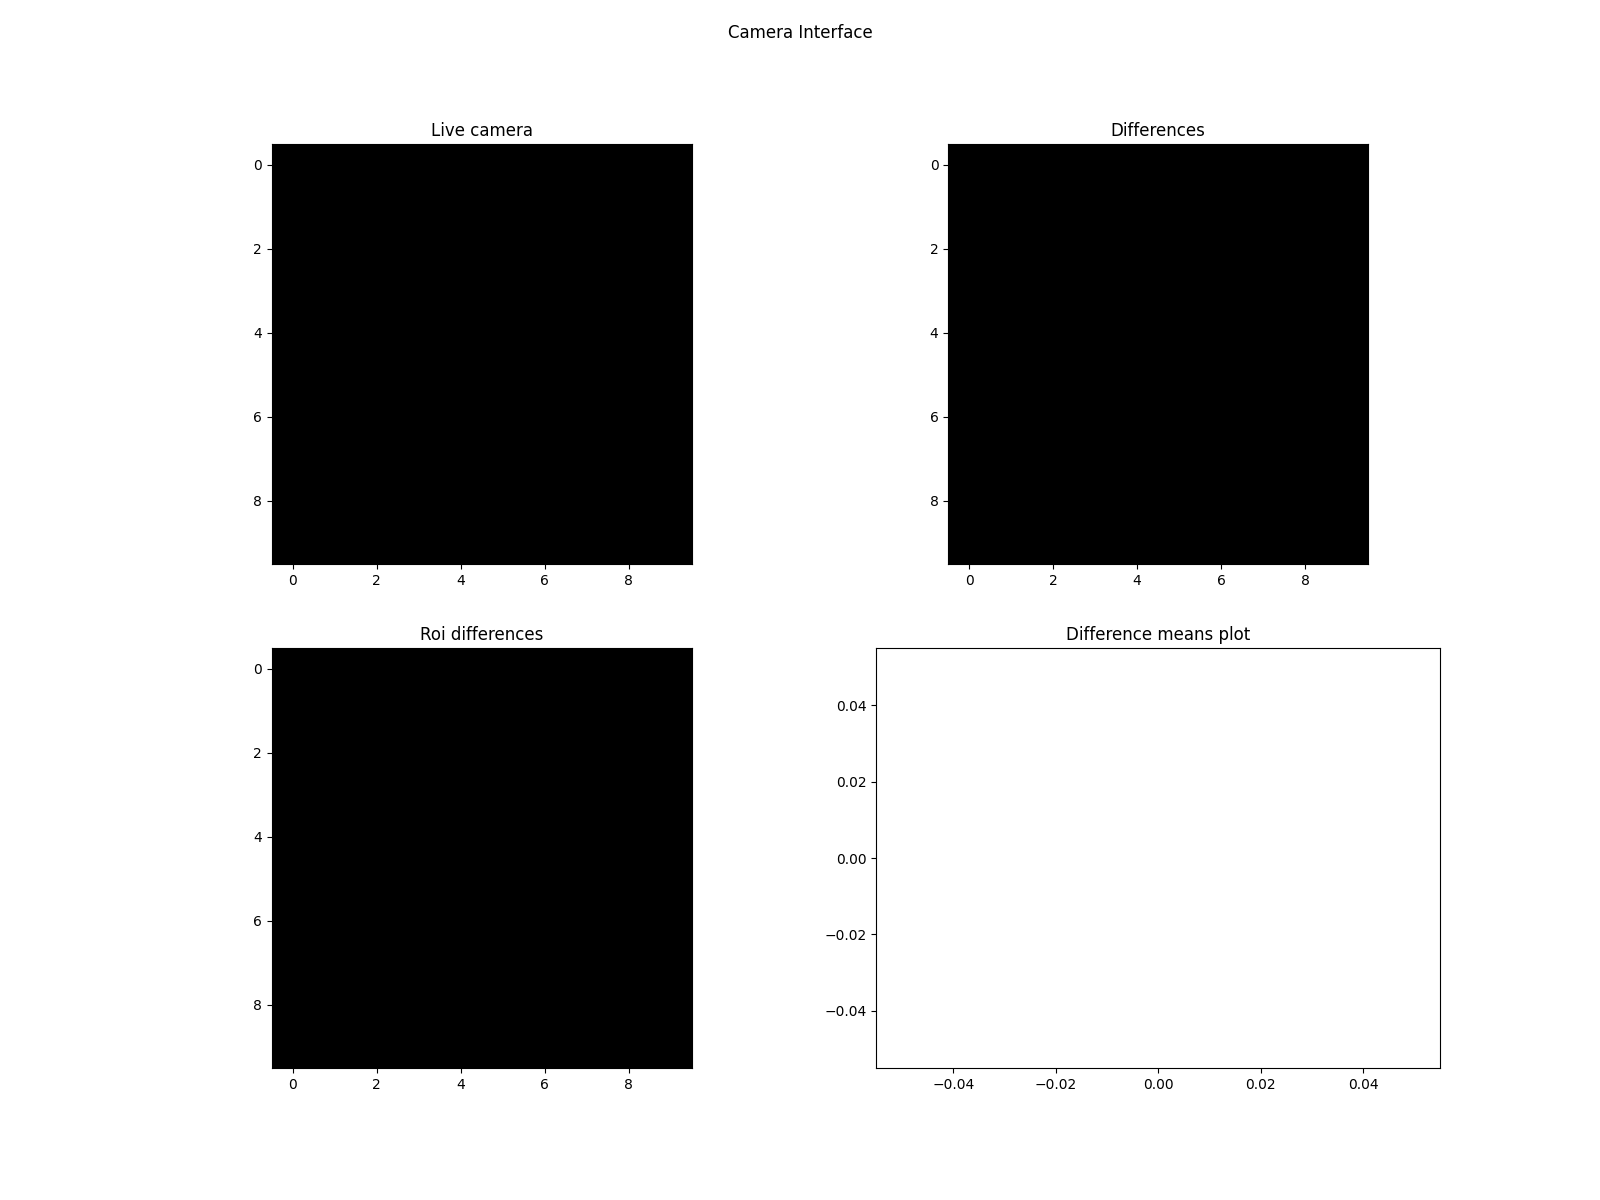

In [5]:
camera_interface = CameraInterface()

Output()

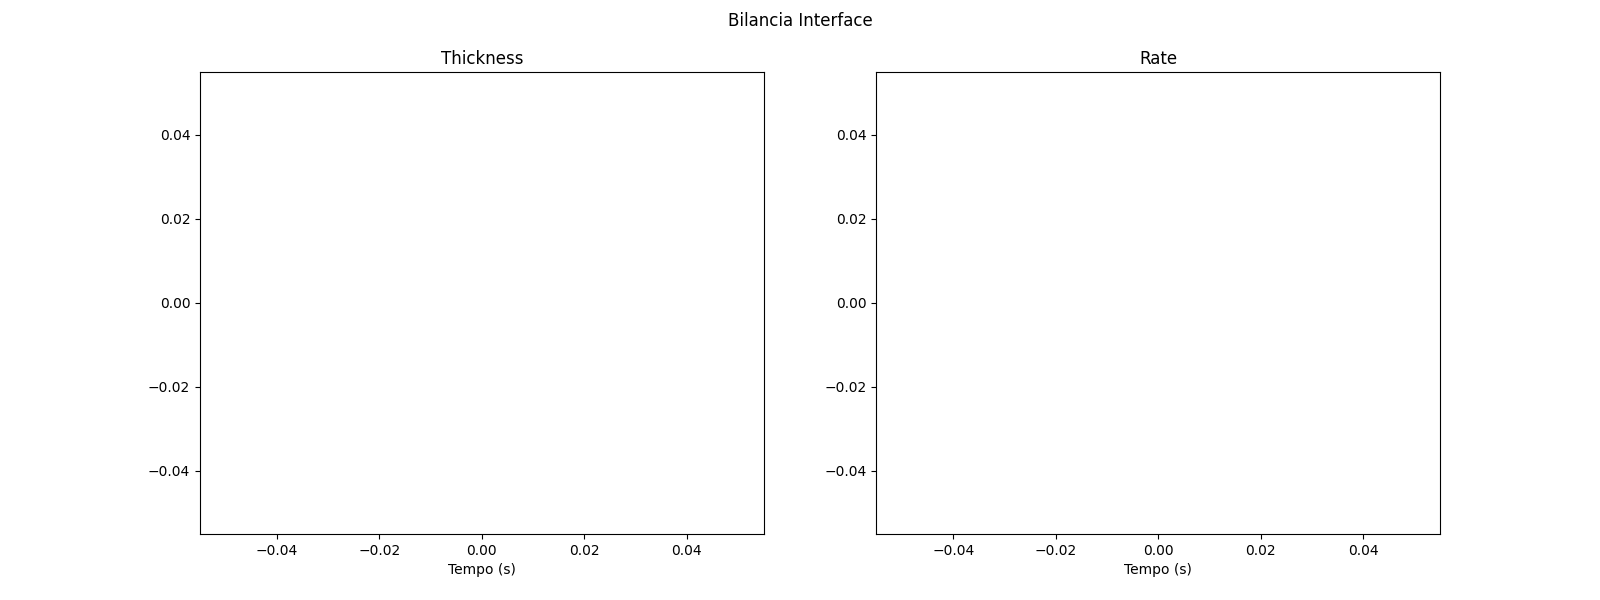

In [6]:
bilancia_interface = BilanciaInterface()

Output()

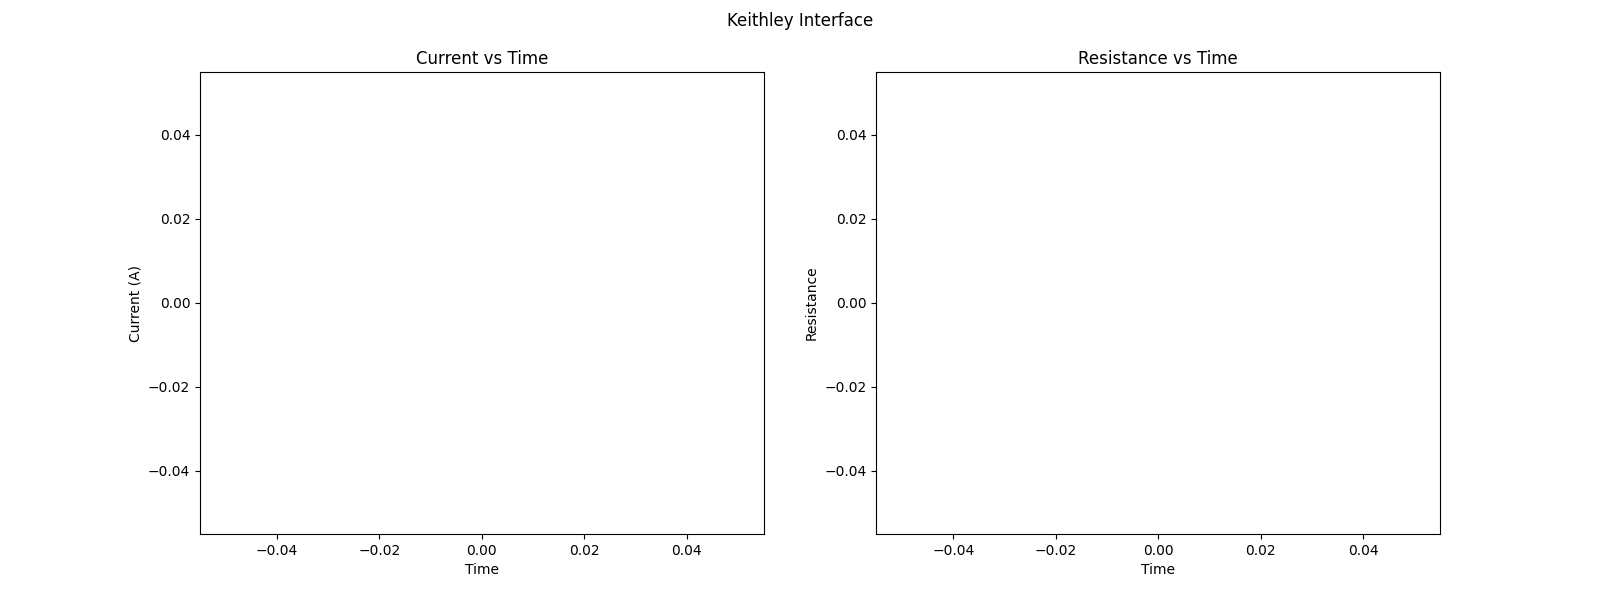

In [7]:
elettrometro_interface = ElectrometerInterface()